# 24 -- Finding real users and movies that illustrate the $\Delta E$ quadrants

Notebook 23 introduced the $\Delta_1$/$\Delta_2$ quadrant diagnostic (per test pair) and its 5,000-user aggregate. This notebook answers a follow-up question directly with data, not with assumed categories: **which specific users and movies actually show each quadrant most strongly?**

Method: compute $\Delta_1$, $\Delta_2$ and the quadrant for every one of the 1,032,307 test pairs (identical formulas to notebook 23's Part B), then aggregate by user and separately by movie, keeping only groups with enough test pairs to be statistically meaningful (>=30 pairs for users, >=100 for movies -- these are sample-size floors, not category thresholds), and rank by each quadrant's share. No user or movie is picked in advance -- the ranking is entirely a function of the computed data.

## Part 0 -- Setup (identical to notebook 23)

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

K = 10
RATING_LEVELS = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


def softmax(x, axis=-1):
    x = x - x.max(axis=axis, keepdims=True)
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)


W1 = np.load(proc / "rbmB1_weights_5k.npy")
bh1 = np.load(proc / "rbmB1_bias_hidden_5k.npy")
W2 = np.load(proc / "rbmB2_weights_5k.npy")
bh2 = np.load(proc / "rbmB2_bias_hidden_5k.npy")
channelB1 = np.load(proc / "channelB1_softmax.npy", mmap_mode="r")
channelB2 = np.load(proc / "channelB2_personality.npy", mmap_mode="r")
cohort_user_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)
user_means = np.load(proc / "user_means.npy").astype(np.float64)
test_labels = pd.read_csv(proc / "test_labels.csv")
mu_global = float(np.load(proc / "mu_global.npy"))
movies_title_map = pd.read_csv(root / "data" / "movie.csv").set_index("movieId")["title"].to_dict()

n_users, n_movies, _ = channelB1.shape
n_hidden = bh1.shape[0]
user_to_row = {int(uid): i for i, uid in enumerate(cohort_user_ids)}
row_to_user = {i: int(uid) for uid, i in user_to_row.items()}
movie_to_col = {int(mid): j for j, mid in enumerate(movie_vocab)}
col_to_movie = {j: int(mid) for mid, j in movie_to_col.items()}
W1_r = W1.reshape(n_movies, K, n_hidden)

X1 = np.asarray(channelB1, dtype=np.float32).reshape(n_users, -1)
X2 = np.asarray(channelB2, dtype=np.float32).reshape(n_users, -1)
H1 = sigmoid(X1 @ W1 + bh1)
H2 = sigmoid(X2 @ W2 + bh2)

print(f"n_users={n_users}  n_movies={n_movies}  n_hidden={n_hidden}")

n_users=5000  n_movies=13129  n_hidden=128


## Part 1 -- $\Delta_1$, $\Delta_2$, quadrant for every test pair

Same batched-by-movie computation as notebook 23's Part B.

In [8]:
tl = test_labels.copy()
tl["user_row"] = tl["userId"].map(user_to_row)
tl["movie_col"] = tl["movieId"].map(movie_to_col)
tl = tl.dropna(subset=["user_row", "movie_col"]).copy()
tl["user_row"] = tl["user_row"].astype(int)
tl["movie_col"] = tl["movie_col"].astype(int)
tl["k_star"] = np.round(tl["rating"].values * 2).astype(int) - 1

n_test = len(tl)
Delta1_all = np.empty(n_test, dtype=np.float64)
Delta2_all = np.empty(n_test, dtype=np.float64)

tl_reset = tl.reset_index(drop=True)
for movie_col, g in tl_reset.groupby("movie_col"):
    idx = g.index.values
    urows = g["user_row"].values
    kstars = g["k_star"].values

    h1_batch = H1[urows]
    h2_batch = H2[urows]

    W_slice1 = W1_r[movie_col]
    J1 = h1_batch @ W_slice1.T
    P1 = softmax(J1, axis=1)
    e1_true = -J1[np.arange(len(idx)), kstars]
    e1_pred = -(P1 * J1).sum(axis=1)
    Delta1_all[idx] = e1_pred - e1_true

    W_slice2 = W2[movie_col]
    J2 = h2_batch @ W_slice2
    personality_true = user_means[urows] - mu_global
    v_recon2 = sigmoid(J2)
    e2_true = -personality_true * J2
    e2_pred = -v_recon2 * J2
    Delta2_all[idx] = e2_pred - e2_true

tl_reset["Delta1"] = Delta1_all
tl_reset["Delta2"] = Delta2_all


def classify_quadrant(d1, d2):
    q = np.full(len(d1), "", dtype="<U2")
    q[(d1 > 0) & (d2 > 0)] = "Q1"
    q[(d1 < 0) & (d2 < 0)] = "Q2"
    q[(d1 > 0) & (d2 < 0)] = "Q3"
    q[(d1 < 0) & (d2 > 0)] = "Q4"
    return q


tl_reset["quadrant"] = classify_quadrant(Delta1_all, Delta2_all)
print(f"{len(tl_reset):,} test pairs processed")

1,032,307 test pairs processed


## Part 2 -- most extreme users, by quadrant share

Sample-size floor: only users with >=30 test pairs are eligible for ranking (a user with 2 test pairs landing 100% in one quadrant is noise, not signal).

In [9]:
QUAD = ["Q1", "Q2", "Q3", "Q4"]
QUAD_LABEL = {"Q1": "Q1 nothing", "Q2": "Q2 change both", "Q3": "Q3 change e-", "Q4": "Q4 change e+"}
MIN_N_USER = 30

per_user = tl_reset.groupby("user_row")["quadrant"].value_counts().unstack(fill_value=0)
for q in QUAD:
    if q not in per_user.columns:
        per_user[q] = 0
per_user["n"] = per_user[QUAD].sum(axis=1)
per_user_elig = per_user[per_user["n"] >= MIN_N_USER].copy()
for q in QUAD:
    per_user_elig[f"{q}_prop"] = per_user_elig[q] / per_user_elig["n"]

print(f"{len(per_user_elig)} / {len(per_user)} users have >= {MIN_N_USER} test pairs and are eligible for ranking")
print()
top_users = {}
for q in QUAD:
    top = per_user_elig.sort_values(f"{q}_prop", ascending=False).head(3)
    top_users[q] = top
    print(f"-- highest {QUAD_LABEL[q]} share --")
    for row, r in top.iterrows():
        print(f"  user {row_to_user[row]}: n={int(r['n'])}  {q}_prop={r[f'{q}_prop']:.3f}  "
              f"(Q1={int(r['Q1'])}, Q2={int(r['Q2'])}, Q3={int(r['Q3'])}, Q4={int(r['Q4'])})")
    print()

5000 / 5000 users have >= 30 test pairs and are eligible for ranking

-- highest Q1 nothing share --
  user 94379: n=172  Q1_prop=0.983  (Q1=169, Q2=0, Q3=0, Q4=3)
  user 11343: n=153  Q1_prop=0.908  (Q1=139, Q2=0, Q3=0, Q4=14)
  user 18765: n=250  Q1_prop=0.904  (Q1=226, Q2=0, Q3=0, Q4=24)

-- highest Q2 change both share --
  user 113895: n=164  Q2_prop=0.902  (Q1=0, Q2=148, Q3=16, Q4=0)
  user 2757: n=158  Q2_prop=0.842  (Q1=0, Q2=133, Q3=25, Q4=0)
  user 86206: n=125  Q2_prop=0.816  (Q1=0, Q2=102, Q3=23, Q4=0)

-- highest Q3 change e- share --
  user 26820: n=165  Q3_prop=0.788  (Q1=0, Q2=35, Q3=130, Q4=0)
  user 117015: n=239  Q3_prop=0.778  (Q1=0, Q2=53, Q3=186, Q4=0)
  user 5814: n=170  Q3_prop=0.776  (Q1=0, Q2=38, Q3=132, Q4=0)

-- highest Q4 change e+ share --
  user 30519: n=161  Q4_prop=0.969  (Q1=5, Q2=0, Q3=0, Q4=156)
  user 107214: n=149  Q4_prop=0.933  (Q1=10, Q2=0, Q3=0, Q4=139)
  user 22942: n=145  Q4_prop=0.917  (Q1=12, Q2=0, Q3=0, Q4=133)



## Part 3 -- most extreme movies, by quadrant share

Same idea, aggregated by movie instead of user. Sample-size floor: >=100 test pairs (movies get many more raters than a single user gets ratings, so a higher floor keeps the same statistical-reliability standard).

In [10]:
MIN_N_MOVIE = 100

per_movie = tl_reset.groupby("movie_col")["quadrant"].value_counts().unstack(fill_value=0)
for q in QUAD:
    if q not in per_movie.columns:
        per_movie[q] = 0
per_movie["n"] = per_movie[QUAD].sum(axis=1)
per_movie_elig = per_movie[per_movie["n"] >= MIN_N_MOVIE].copy()
for q in QUAD:
    per_movie_elig[f"{q}_prop"] = per_movie_elig[q] / per_movie_elig["n"]

print(f"{len(per_movie_elig)} / {len(per_movie)} movies have >= {MIN_N_MOVIE} test pairs and are eligible for ranking")
print()
top_movies = {}
for q in QUAD:
    top = per_movie_elig.sort_values(f"{q}_prop", ascending=False).head(3)
    top_movies[q] = top
    print(f"-- highest {QUAD_LABEL[q]} share --")
    for col, r in top.iterrows():
        title = movies_title_map.get(col_to_movie[col], "?")
        print(f"  {title}: n={int(r['n'])}  {q}_prop={r[f'{q}_prop']:.3f}  "
              f"(Q1={int(r['Q1'])}, Q2={int(r['Q2'])}, Q3={int(r['Q3'])}, Q4={int(r['Q4'])})")
    print()

3334 / 13115 movies have >= 100 test pairs and are eligible for ranking

-- highest Q1 nothing share --
  American Reunion (American Pie 4) (2012): n=108  Q1_prop=0.824  (Q1=89, Q2=0, Q3=3, Q4=16)
  Guard, The (2011): n=183  Q1_prop=0.814  (Q1=149, Q2=2, Q3=11, Q4=21)
  Rare Exports: A Christmas Tale (Rare Exports) (2010): n=110  Q1_prop=0.809  (Q1=89, Q2=2, Q3=2, Q4=17)

-- highest Q2 change both share --
  Year of Living Dangerously, The (1982): n=108  Q2_prop=0.148  (Q1=31, Q2=16, Q3=7, Q4=54)
  In the Company of Men (1997): n=131  Q2_prop=0.137  (Q1=35, Q2=18, Q3=3, Q4=75)
  Ladykillers, The (1955): n=102  Q2_prop=0.137  (Q1=32, Q2=14, Q3=8, Q4=48)

-- highest Q3 change e- share --
  Victor/Victoria (1982): n=126  Q3_prop=0.143  (Q1=49, Q2=12, Q3=18, Q4=47)
  Silkwood (1983): n=115  Q3_prop=0.139  (Q1=44, Q2=14, Q3=16, Q4=41)
  Bob Roberts (1992): n=125  Q3_prop=0.136  (Q1=42, Q2=8, Q3=17, Q4=58)

-- highest Q4 change e+ share --
  Stoker (2013): n=116  Q4_prop=0.776  (Q1=20, Q2=2,

## Part 4 -- the sharpest contrast: one Q1-dominant user vs. one Q4-dominant user

The single most striking pair from Part 2: the top-ranked Q1 user (the model agrees with almost every one of his test ratings) against the top-ranked Q4 user (the e+ channel is wrong on almost every one of his test ratings, while e- is not).

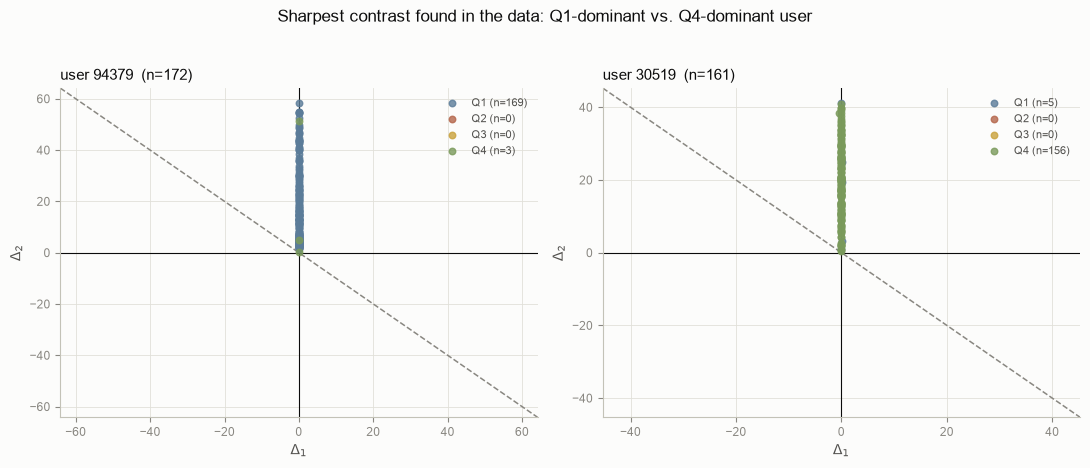

In [11]:
user_q1 = int(top_users["Q1"].index[0])
user_q4 = int(top_users["Q4"].index[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor="#fcfcfb")
INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
QUADRANT_COLORS = {"Q1": "#5b7c99", "Q2": "#b4654a", "Q3": "#c9a13b", "Q4": "#7a9a5b"}
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

for ax, row in zip(axes, [user_q1, user_q4]):
    uid = row_to_user[row]
    sub = tl_reset[tl_reset["user_row"] == row]
    ax.set_facecolor(SURFACE)
    for q, color in QUADRANT_COLORS.items():
        s = sub[sub["quadrant"] == q]
        ax.scatter(s["Delta1"], s["Delta2"], color=color, s=22, alpha=0.8, zorder=3, label=f"{q} (n={len(s)})")
    lim = max(np.abs(sub["Delta1"]).max(), np.abs(sub["Delta2"]).max()) * 1.1
    ax.plot([-lim, lim], [lim, -lim], color=INK_MUTED, linewidth=1.1, linestyle="--", zorder=2)
    ax.axhline(0, color=INK_PRIMARY, linewidth=0.8, zorder=2)
    ax.axvline(0, color=INK_PRIMARY, linewidth=0.8, zorder=2)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"$\Delta_1$", color=INK_SECONDARY, fontsize=10)
    ax.set_ylabel(r"$\Delta_2$", color=INK_SECONDARY, fontsize=10)
    ax.set_title(f"user {uid}  (n={len(sub)})", color=INK_PRIMARY, fontsize=11, loc="left")
    ax.legend(loc="best", frameon=False, fontsize=8, labelcolor=INK_SECONDARY)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    for s_ in ("left", "bottom"):
        ax.spines[s_].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)
    ax.grid(color=GRID, linewidth=0.6, zorder=0)

fig.suptitle("Sharpest contrast found in the data: Q1-dominant vs. Q4-dominant user", fontsize=12, color=INK_PRIMARY, y=1.03)
plt.tight_layout()
plt.savefig(out_dir / "deltaE_user_contrast_5k.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

## Part 5 -- the sharpest contrast: one Q1-dominant movie vs. one Q4-dominant movie

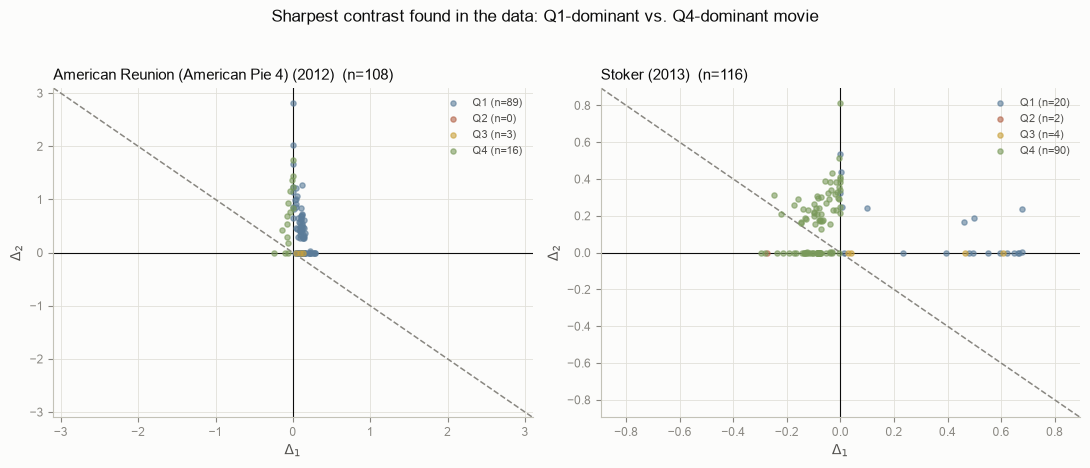

In [12]:
movie_q1 = int(top_movies["Q1"].index[0])
movie_q4 = int(top_movies["Q4"].index[0])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), facecolor="#fcfcfb")
for ax, col in zip(axes, [movie_q1, movie_q4]):
    mid = col_to_movie[col]
    title = movies_title_map.get(mid, "?")
    sub = tl_reset[tl_reset["movie_col"] == col]
    ax.set_facecolor(SURFACE)
    for q, color in QUADRANT_COLORS.items():
        s = sub[sub["quadrant"] == q]
        ax.scatter(s["Delta1"], s["Delta2"], color=color, s=14, alpha=0.6, zorder=3, label=f"{q} (n={len(s)})")
    lim = max(np.abs(sub["Delta1"]).max(), np.abs(sub["Delta2"]).max()) * 1.1
    ax.plot([-lim, lim], [lim, -lim], color=INK_MUTED, linewidth=1.1, linestyle="--", zorder=2)
    ax.axhline(0, color=INK_PRIMARY, linewidth=0.8, zorder=2)
    ax.axvline(0, color=INK_PRIMARY, linewidth=0.8, zorder=2)
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel(r"$\Delta_1$", color=INK_SECONDARY, fontsize=10)
    ax.set_ylabel(r"$\Delta_2$", color=INK_SECONDARY, fontsize=10)
    ax.set_title(f"{title}  (n={len(sub)})", color=INK_PRIMARY, fontsize=10.5, loc="left")
    ax.legend(loc="best", frameon=False, fontsize=8, labelcolor=INK_SECONDARY)
    for s_ in ("top", "right"):
        ax.spines[s_].set_visible(False)
    for s_ in ("left", "bottom"):
        ax.spines[s_].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8.5)
    ax.grid(color=GRID, linewidth=0.6, zorder=0)

fig.suptitle("Sharpest contrast found in the data: Q1-dominant vs. Q4-dominant movie", fontsize=12, color=INK_PRIMARY, y=1.03)
plt.tight_layout()
plt.savefig(out_dir / "deltaE_movie_contrast_5k.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()